In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [15]:
df = pd.read_csv("airline_operations1.csv")
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [16]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (318017, 21)

Columns:
Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 318017 non-null  int64  
 1   month                318017 non-null  int64  
 2   carrier              318013 non-null  object 
 3   carrier_name         318013 non-null  object 
 4   airport              318014 non-null  object 
 5   airport_name         318017 non-null  object 
 6   arr_flights          317524 non-null  float64
 7   arr_del15            317285 non-null  float64
 8   carrier_ct           317525 non-null  float64
 9   weather_ct           317523 non-null  float64
 10  nas_ct               317529 non-null  float64
 11  security_ct          317529 non-null  float64
 12  late_aircraft_ct     317529 non-null  float64
 13  arr_cancelled        317529 non-null  float64
 14  arr_diverted         317527 non-null  float64
 15  arr_delay        

In [18]:
df.isnull().sum()

year                     0
month                    0
carrier                  4
carrier_name             4
airport                  3
airport_name             0
arr_flights            493
arr_del15              732
carrier_ct             492
weather_ct             494
nas_ct                 488
security_ct            488
late_aircraft_ct       488
arr_cancelled          488
arr_diverted           490
arr_delay              494
carrier_delay          492
weather_delay          488
nas_delay              488
security_delay         490
late_aircraft_delay    488
dtype: int64

In [19]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

df[["month","season"]].head()

,month,season
0,5,Spring
1,5,Spring
2,5,Spring
3,5,Spring
4,5,Spring


In [20]:
airport_delay = (
    df.groupby("airport_name")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

airport_delay

airport_name
Chicago, IL: Chicago O'Hare International                 31856.429897
Atlanta, GA: Hartsfield-Jackson Atlanta International     27830.672920
Dallas/Fort Worth, TX: Dallas/Fort Worth International    20564.119723
Newark, NJ: Newark Liberty International                  17491.663831
San Francisco, CA: San Francisco International            16140.159024
Sanford, FL: Orlando Sanford International                16041.452830
Denver, CO: Denver International                          15015.480447
New York, NY: John F. Kennedy International               14635.326951
Los Angeles, CA: Los Angeles International                13589.449130
Houston, TX: George Bush Intercontinental/Houston         13375.582714
Name: arr_delay, dtype: float64

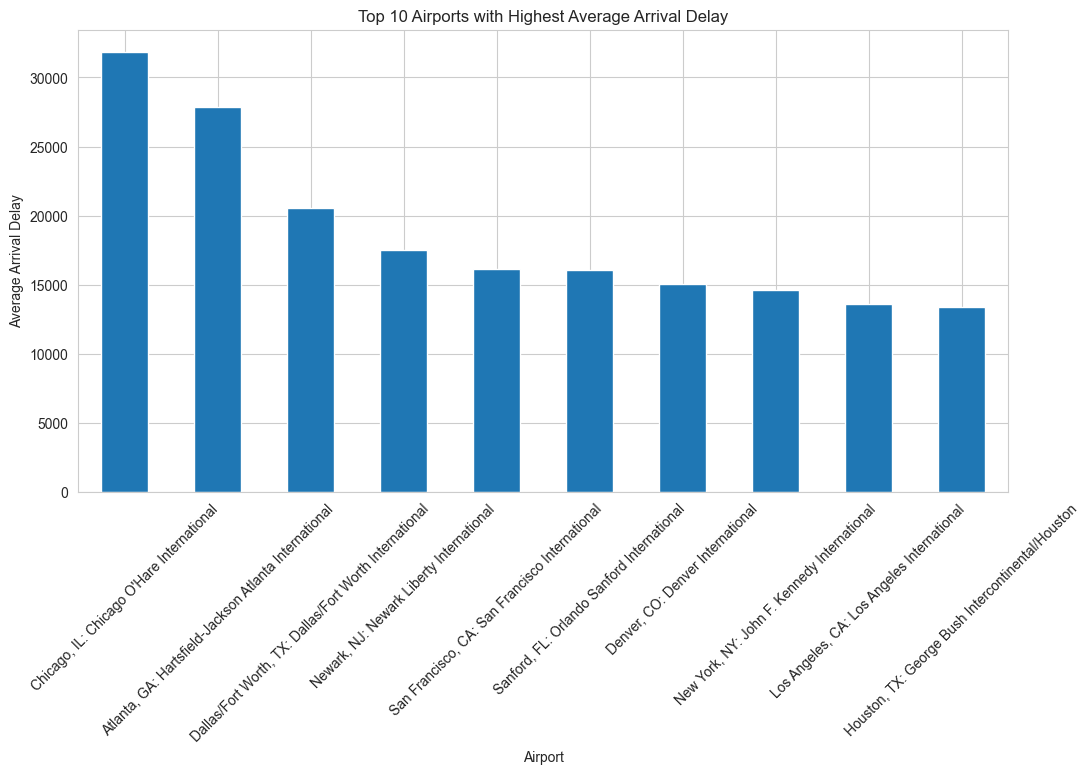

In [21]:
plt.figure(figsize=(12,6))
airport_delay.plot(kind="bar")
plt.title("Top 10 Airports with Highest Average Arrival Delay")
plt.xlabel("Airport")
plt.ylabel("Average Arrival Delay")
plt.xticks(rotation=45)
plt.show()

In [22]:
seasonal_delay = df.groupby("season")[["arr_delay"]].mean()

seasonal_delay

,arr_delay
season,
Autumn,3171.508894
Spring,4001.199244
Summer,5314.679977
Winter,4356.616610


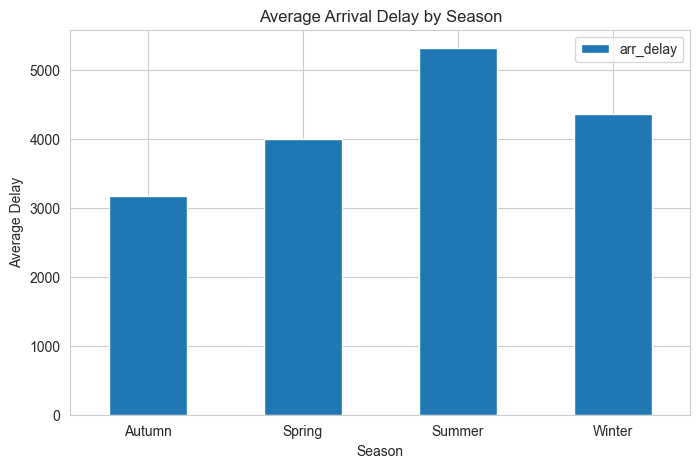

In [23]:
seasonal_delay.plot(kind="bar", figsize=(8,5))
plt.title("Average Arrival Delay by Season")
plt.xlabel("Season")
plt.ylabel("Average Delay")
plt.xticks(rotation=0)
plt.show()

In [24]:
cancel_analysis = df.groupby("season")["arr_cancelled"].sum()

cancel_analysis

season
Autumn    339679.0
Spring    678798.0
Summer    502912.0
Winter    767124.0
Name: arr_cancelled, dtype: float64

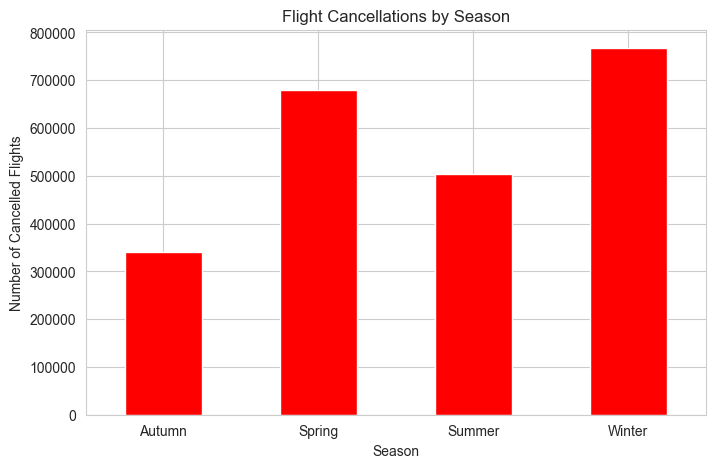

In [25]:
plt.figure(figsize=(8,5))
cancel_analysis.plot(kind="bar", color="red")
plt.title("Flight Cancellations by Season")
plt.xlabel("Season")
plt.ylabel("Number of Cancelled Flights")
plt.xticks(rotation=0)
plt.show()

In [26]:
delay_causes = df[[
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"
]].mean()

delay_causes

carrier_delay          1286.577224
weather_delay           220.567542
nas_delay              1099.516422
security_delay            7.214845
late_aircraft_delay    1596.062993
dtype: float64

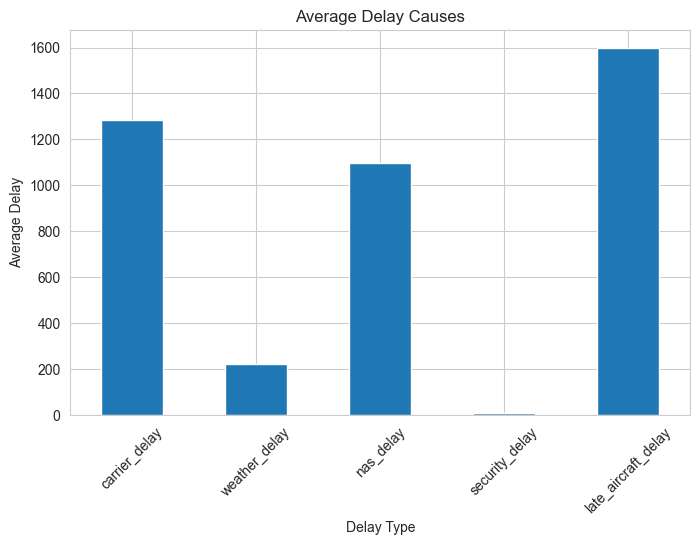

In [27]:
plt.figure(figsize=(8,5))
delay_causes.plot(kind="bar")
plt.title("Average Delay Causes")
plt.xlabel("Delay Type")
plt.ylabel("Average Delay")
plt.xticks(rotation=45)
plt.show()

In [28]:
airline_delay = (
    df.groupby("carrier_name")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

airline_delay

carrier_name
Southwest Airlines Co.          11242.021393
American Airlines Inc.           8026.986651
United Air Lines Inc.            5975.122717
JetBlue Airways                  5427.566482
Delta Air Lines Inc.             4573.353858
US Airways Inc.                  4517.774712
Continental Air Lines Inc.       4342.163265
Spirit Air Lines                 4325.828549
American Eagle Airlines Inc.     4182.537038
ExpressJet Airlines Inc.         4003.463350
Name: arr_delay, dtype: float64

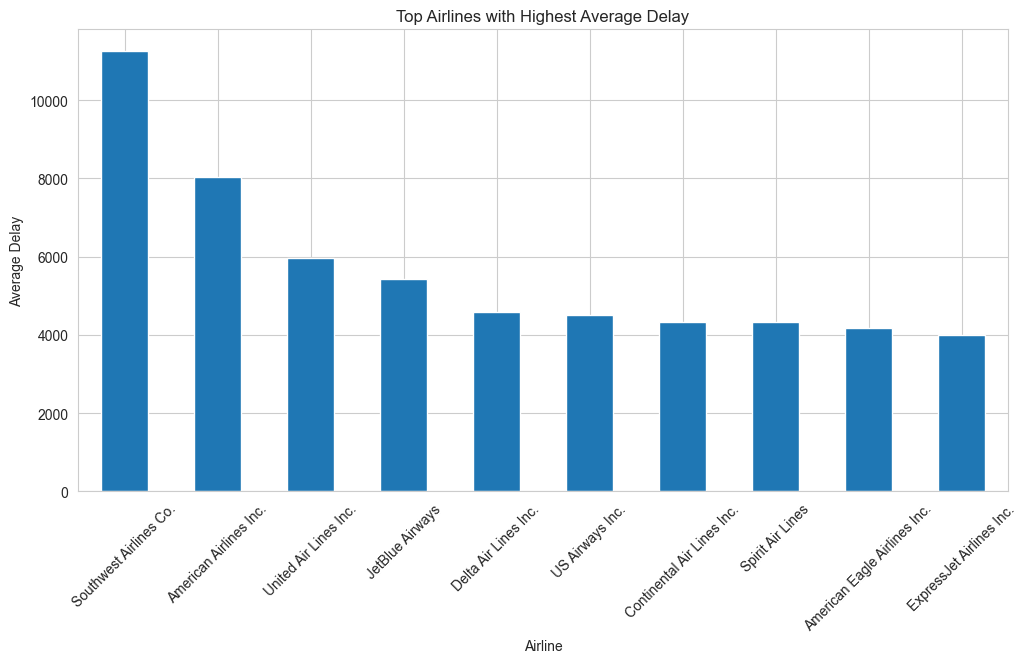

In [29]:
plt.figure(figsize=(12,6))
airline_delay.plot(kind="bar")
plt.title("Top Airlines with Highest Average Delay")
plt.xlabel("Airline")
plt.ylabel("Average Delay")
plt.xticks(rotation=45)
plt.show()

This pull request includes Milestone 3 analysis focusing on:

1.Route-level delay insights
2.Seasonal performance trends
3.Cancellation analysis
4.Arrival and Departure delay comparison
5.Visualization of delay causes by season
6.The analysis provides operational insights into congestion patterns,
seasonal traffic impact, and route-level performance metrics.